In [1]:
!pip install nevergrad

import warnings

import matplotlib.pyplot as plt
import nevergrad
import numpy
import pandas
import scipy.stats
import seaborn
import sklearn.base
import sklearn.compose
import sklearn.inspection
import sklearn.linear_model
import sklearn.model_selection
import sklearn.preprocessing
from IPython.core.display import display

# nevergrad appelle COBYLA de SciPy avec une tolérance que SciPy corrige.
warnings.filterwarnings("ignore", message="COBYLA: Invalid RHOEND")

In [2]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s ames

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 422.90 KiB | 6.61 MiB/s, done.
Resolving deltas: 100% (2/2), done.
✓ ames — 8 fichiers, 4.6M


# Régression linéaire

## Régression linéaire univariée

### Introduction

La régression linéaire est très intéressante à coder soi-même : elle n'est pas trop complexe mais permet de toucher à beaucoup de concepts du machine learning.

Nous allons continuer notre travail sur les données de prix de maisons.

Passons en python quelques secondes pour charger le dataset :

In [3]:
train_df = pandas.read_csv("ames/train.csv", index_col="Id")

In [4]:
display(train_df)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


### Colonnes utilisées

Nous utiliserons dans cette démonstration seulement une caractéristique : `GrLivArea`, et `SalePrice` comme target.

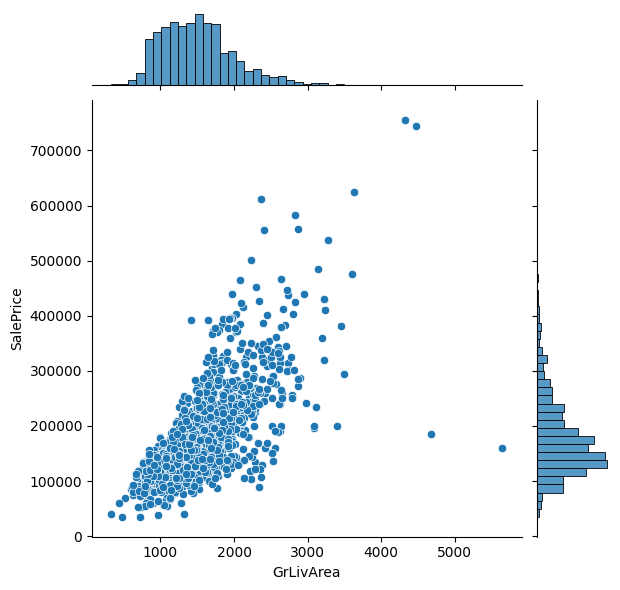

In [5]:
seaborn.jointplot(x="GrLivArea", y="SalePrice", data=train_df)
plt.show()

In [6]:
# Standardize X
X_scaler = sklearn.preprocessing.StandardScaler()
X = X_scaler.fit_transform(train_df[["GrLivArea"]].to_numpy())

# Standardize y
Y_scaler = sklearn.preprocessing.StandardScaler()
Y = Y_scaler.fit_transform(train_df[["SalePrice"]])

### Exemple de Régression Linéaire
Pour comprendre l'évolution jointe du prix de vente et de la qualité globale d'une maison, on va se limiter à une hypothèse forte : on peut trouver une fonction affine qui modélise correctement la relation entre les entrées et les sorties. Pour rappel, une fonction affine est de la forme $h_\theta(x) = \theta_0 + \theta_1 x$.

Géométriquement, on pourra représenter cette fonction par une droite.

Par exemple, ici, on aimerait trouver l'hypothèse suivante :

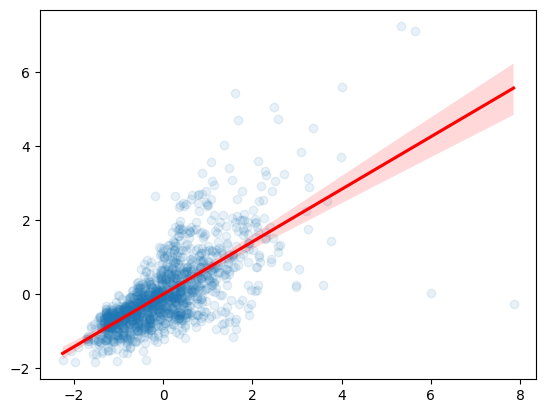

In [7]:
seaborn.regplot(x=X, y=Y, scatter_kws=dict(alpha=0.10), line_kws=dict(color="red"))
plt.show()

Tout ça est prometteur, mais ici nous avons utilisé [`seaborn`](https://seaborn.pydata.org/) pour calculer les paramètres de l'hypothèse qui représente au mieux les données. Nous allons maintenant voir comment le faire nous même.

### Estimation des paramètres

Pour estimer $\theta_0$ et $\theta_1$, nous avons besoin de 2 éléments :

- une fonction de coût, qui nous dira pour des paramètres donnés $\theta_0$ et $\theta_1$ si l'on se débrouille bien ou non
- une méthode d'estimation des meilleurs paramètres étant donnée cette fonction de coût

### Prédictions

En prérequis au calcul de la fonction de coût, nous devons savoir calculer des prédictions.

Pour appliquer la transformation linéaire définie par $\theta_0$ et $\theta_1$ à $\mathbf{x}$, on utilise simplement la multiplication et l'addition de scalaires à un vecteur : $\mathbf{x}\theta_1 + \theta_0$

In [8]:
def predict(X: numpy.ndarray, theta_0: float, theta_1: float) -> numpy.ndarray:
  return theta_0 + X * theta_1


X_example = numpy.array([[1], [2], [3]])
Y_example = numpy.array([[4], [10], [3]])
theta_0_example = 2
theta_1_example = 3

print(predict(X_example, theta_0_example, theta_1_example))

[[ 5]
 [ 8]
 [11]]


### Fonction de coût

La fonction de coût la plus utilisée est la moyenne des différences entre les points réels et ceux obtenus par l'hypothèse avec les paramètres courants, le tout au carré.

En notant $L$ la fonction de coût, $n$ le nombre d'exemples d'apprentissage, on peut écrire :

$$
  L(\theta_0, \theta_1) = \sum\frac{(\mathbf{x}\theta_1 + \theta_0 - \mathbf{y})^2}{2n}
$$

In [9]:
def residuals(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  theta_0: float,
  theta_1: float,
) -> numpy.ndarray:
  return predict(X, theta_0, theta_1) - Y


print("Residuals:", residuals(X_example, Y_example, theta_0_example, theta_1_example))


def cost(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  theta_0: float,
  theta_1: float,
) -> numpy.float32:
  return numpy.mean(residuals(X=X, Y=Y, theta_0=theta_0, theta_1=theta_1) ** 2) / 2


print("Costs:", cost(X_example, Y_example, theta_0_example, theta_1_example))

Residuals: [[ 1]
 [-2]
 [ 8]]
Costs: 11.5


### Optimisation des paramètres

Optimiser les paramètres revient à minimiser la fonction de coût :

$$\min_{\theta} \sum\frac{(\theta_0 + \mathbf{x}\theta_1 - \mathbf{y})^2}{2n}$$

Pour ce faire, il existe une formule directe que nous n'utiliserons pas dans ces travaux pratiques pour deux raisons : elle n'est pas applicable aux très grands datasets et la méthode que l'on va utiliser pourra être réutilisée pour la régression logistique et d'autres techniques (réseaux de neurones généraux, gradient boosted trees, etc).

Nous allons utiliser la descente de gradient. Cette méthode est itérative et fait des pas successifs en suivant la dérivée (pour maximiser) ou son opposé (pour minimiser) la fonction de perte. Dans le cas de la régression linéaire, elle converge vers l'optimum global (la meilleure solution).

En pseudo-code, l'algorithme est (avec les bons gradients calculés):

$$
\begin{aligned}
& \text{tant que ça n'a pas convergé :} \\
& \quad \theta_0 \leftarrow \theta_0 - \alpha \sum\frac{\theta_0 + \mathbf{x}\theta_1 - \mathbf{y}}{n} \\
& \quad \theta_1 \leftarrow \theta_1 - \alpha \frac{\mathbf{x}^T(\theta_0 + \mathbf{x}\theta_1 - \mathbf{y})}{n} \\
\end{aligned}
$$

où $\alpha$ est le pas d'apprentissage.

In [10]:
def gradient(
  X: numpy.ndarray, Y: numpy.ndarray, theta_0: float, theta_1: float
) -> tuple[float, float]:
  r = residuals(X=X, Y=Y, theta_1=theta_1, theta_0=theta_0)
  g_0 = r.mean()
  g_1 = X.T.dot(r) / Y.size
  return g_0, g_1[0, 0]

### Descente de gradient

In [11]:
def gradient_descent(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  alpha: float = 0.1,
  nb_iter: int = 1000,
  epsilon: float = 10e-6,
) -> tuple[float, float, list[float]]:
  theta_0 = numpy.random.rand(1)[0]
  theta_1 = numpy.random.rand(1)[0]
  print(f"Paramètres initiaux (aléatoires) : θ₀ = {theta_0:.2f}, θ₁ = {theta_1:.2f}")
  initial_cost = cost(X, Y, theta_0, theta_1)
  print(f"Coût initial : {initial_cost:.2f}")
  costs = [initial_cost]
  for i in range(nb_iter):
    g_0, g_1 = gradient(X, Y, theta_0, theta_1)
    theta_0 -= alpha * g_0
    theta_1 -= alpha * g_1
    costs.append(cost(X, Y, theta_0, theta_1))
    if costs[-2] - costs[-1] < epsilon:
      print(f"Arrêt de la procédure : pas de progrès suffisant à l'itération {i}")
      break
  print(f"Paramètres finaux : θ₀ = {theta_0:.2f}, θ₁ = {theta_1:.2f}")
  print(f"Coût final : {costs[-1]:.2f}")
  return theta_0, theta_1, costs


theta_0, theta_1, costs = gradient_descent(X, Y, 0.1, 1000)
print(f"Coûts successifs : {', '.join(map(str, costs))}")

Paramètres initiaux (aléatoires) : θ₀ = 0.79, θ₁ = 0.67
Coût initial : 0.56
Arrêt de la procédure : pas de progrès suffisant à l'itération 42
Paramètres finaux : θ₀ = 0.01, θ₁ = 0.71
Coût final : 0.25
Coûts successifs : 0.5609587041822341, 0.5016724286117882, 0.4536505453997271, 0.4147528199979575, 0.3832456624225242, 0.35772486478642324, 0.3370530187011814, 0.3203088233721355, 0.30674602515560834, 0.29576015860022137, 0.2868616066903579, 0.27965377964336846, 0.2738154397353071, 0.2690863844097773, 0.2652558495960982, 0.2621531163970181, 0.2596399025057633, 0.25760419925384687, 0.2559552796197945, 0.2546196547162121, 0.2535377985443104, 0.2526614950450701, 0.25195168921068534, 0.25137674648483366, 0.2509110428768939, 0.25053382295446264, 0.2502282748172933, 0.2499807808261862, 0.24978031069338943, 0.249617929885824, 0.249486401431696, 0.2493798633838524, 0.24929356756509902, 0.24922366795190878, 0.2491670492652247, 0.2491211881290106, 0.2490840406086772, 0.2490539511172071, 0.249029578

Pour finir l'appel à la fonction gradient_descent

In [12]:
theta_0, theta_1, costs = gradient_descent(X, Y, 0.01, 5000, 10e-6)

Paramètres initiaux (aléatoires) : θ₀ = 0.74, θ₁ = 0.63
Coût initial : 0.52
Arrêt de la procédure : pas de progrès suffisant à l'itération 314
Paramètres finaux : θ₀ = 0.03, θ₁ = 0.71
Coût final : 0.25


### Vérification de notre hypothèse

Vérifions maintenant le modèle appris avec quelques plots :

- valeurs prédites contre les valeurs réelles
- résiduels
- coûts d'entrainement

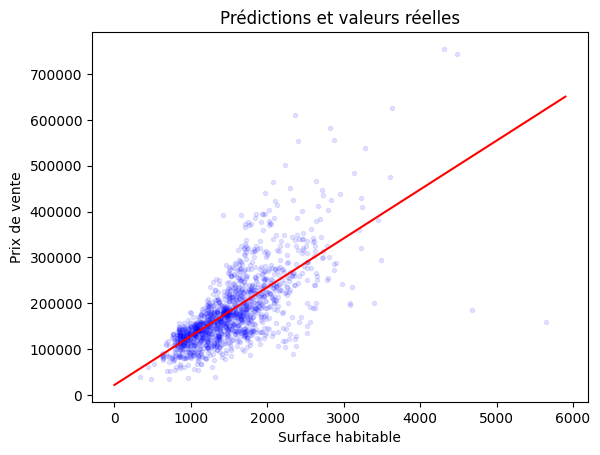

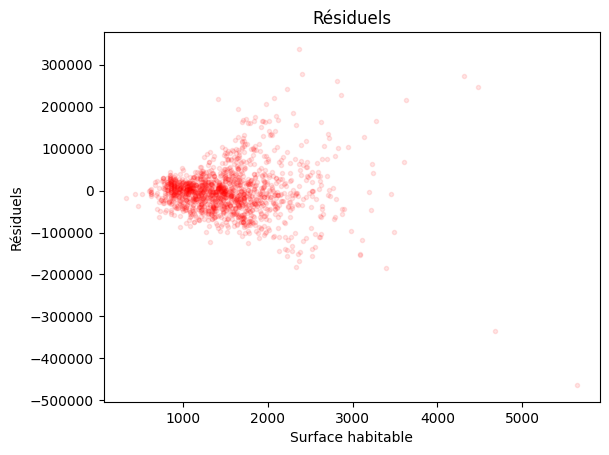

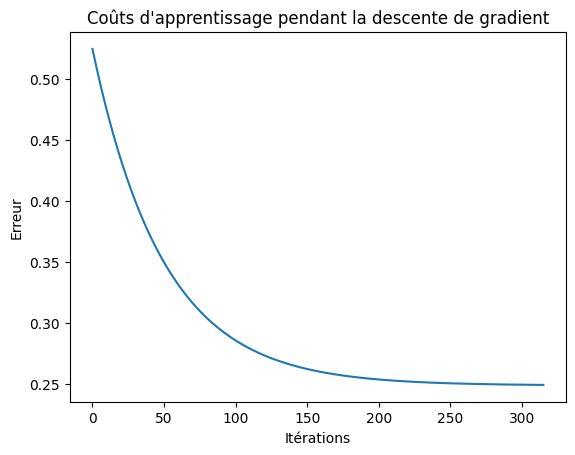

In [13]:
inv_X = X_scaler.inverse_transform(X)
inv_Y = Y_scaler.inverse_transform(Y)
inv_Yh = Y_scaler.inverse_transform(predict(X, theta_0, theta_1))

Xs = numpy.arange(0, 6_000, 100).reshape(-1, 1)
Ys = Y_scaler.inverse_transform(predict(X_scaler.transform(Xs), theta_0, theta_1))
plt.plot(inv_X, inv_Y, "b.", alpha=0.10)
plt.plot(Xs, Ys, "r")
plt.title("Prédictions et valeurs réelles")
plt.xlabel("Surface habitable")
plt.ylabel("Prix de vente")
plt.show()

plt.plot(inv_X, inv_Y - inv_Yh, "r.", alpha=0.10)
plt.title("Résiduels")
plt.xlabel("Surface habitable")
plt.ylabel("Résiduels")
plt.show()

plt.plot(range(len(costs)), costs)
plt.title("Coûts d'apprentissage pendant la descente de gradient")
plt.xlabel("Itérations")
plt.ylabel("Erreur")
plt.show()

### Correction de l'asymétrie positive

Il est intéressant de corriger l'asymétrie positive de la variable de sortie si on l'a remarquée : on peut utiliser pour cela la fonction [`numpy.log1p`](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html) et sa transformation inverse [`numpy.expm1`](https://numpy.org/doc/stable/reference/generated/numpy.expm1.html).

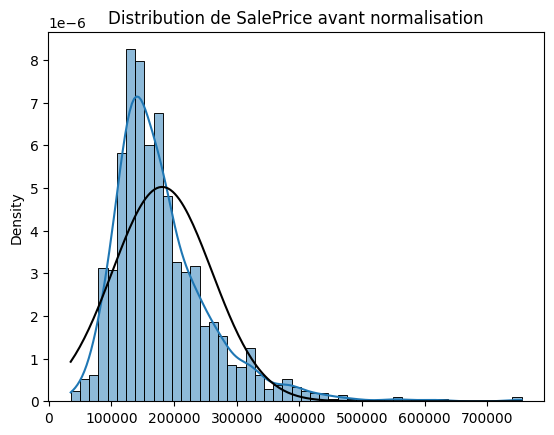

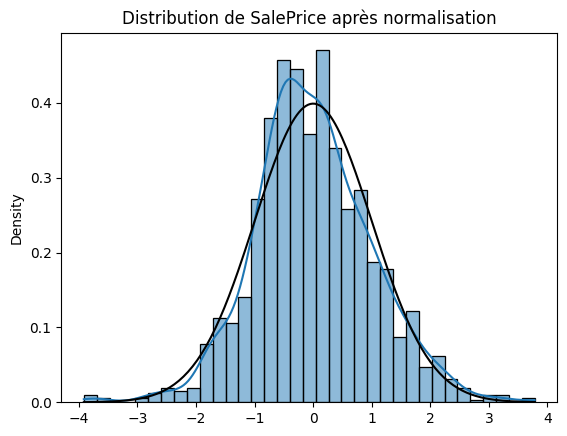

In [14]:
def plot_with_normal_fit(values):
  values = numpy.ravel(values)
  seaborn.histplot(values, stat="density", kde=True)
  xs = numpy.linspace(values.min(), values.max(), 200)
  plt.plot(xs, scipy.stats.norm.pdf(xs, *scipy.stats.norm.fit(values)), "k")


plot_with_normal_fit(train_df["SalePrice"])
plt.title("Distribution de SalePrice avant normalisation")
plt.show()

Y_scaler_log = sklearn.preprocessing.StandardScaler()
Y = Y_scaler_log.fit_transform(numpy.log1p(train_df[["SalePrice"]]))

plot_with_normal_fit(Y)
plt.title("Distribution de SalePrice après normalisation")
plt.show()

Paramètres initiaux (aléatoires) : θ₀ = 0.65, θ₁ = 0.28
Coût initial : 0.56
Arrêt de la procédure : pas de progrès suffisant à l'itération 319
Paramètres finaux : θ₀ = 0.03, θ₁ = 0.68
Coût final : 0.25


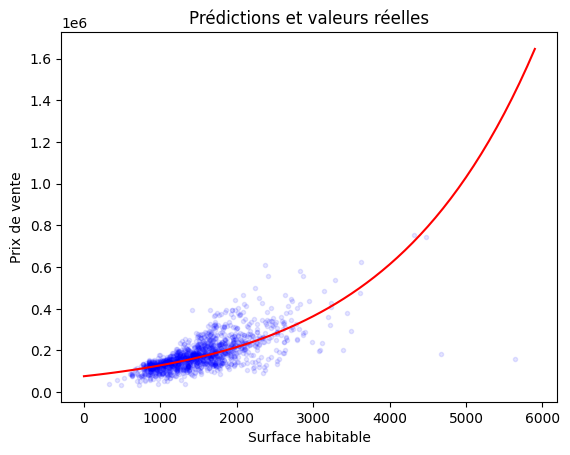

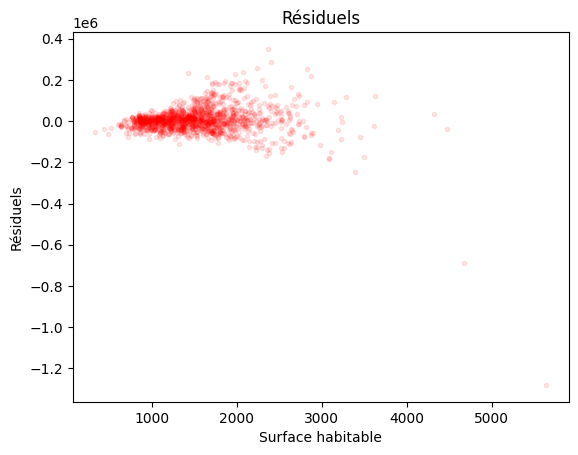

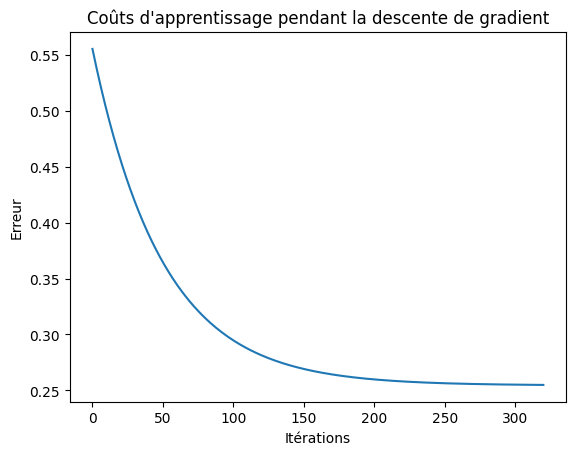

In [15]:
theta_0, theta_1, costs = gradient_descent(X, Y, 0.01, 5000, 10e-6)

inv_X = X_scaler.inverse_transform(X)
inv_Y = numpy.expm1(Y_scaler_log.inverse_transform(Y))
inv_Yh = numpy.expm1(Y_scaler_log.inverse_transform(predict(X, theta_0, theta_1)))

Xs = numpy.arange(0, 6_000, 100).reshape(-1, 1)
Ys = numpy.expm1(
  Y_scaler_log.inverse_transform(predict(X_scaler.transform(Xs), theta_0, theta_1))
)
plt.plot(inv_X, inv_Y, "b.", alpha=0.10)
plt.plot(Xs, Ys, "r")
plt.title("Prédictions et valeurs réelles")
plt.xlabel("Surface habitable")
plt.ylabel("Prix de vente")
plt.show()

plt.plot(inv_X, inv_Y - inv_Yh, "r.", alpha=0.10)
plt.title("Résiduels")
plt.xlabel("Surface habitable")
plt.ylabel("Résiduels")
plt.show()

plt.plot(range(len(costs)), costs)
plt.title("Coûts d'apprentissage pendant la descente de gradient")
plt.xlabel("Itérations")
plt.ylabel("Erreur")
plt.show()

## Régression linéaire multivariée

Pour poursuivre cette démonstration, nous allons reprendre un prétraitement complet effectué sur la totalité des données AMES (et non pas seulement la colonne `GrLiveArea`).

In [16]:
def preprocess(train_file: str, test_file: str) -> numpy.ndarray:
  train_X = pandas.read_csv(train_file, index_col="Id")
  test_X = pandas.read_csv(test_file, index_col="Id")

  train_Y = train_X[["SalePrice"]]
  train_X = train_X.drop(columns="SalePrice")

  all_X = pandas.concat([train_X, test_X])

  # Fill with median
  cols_1 = ["LotFrontage"]
  all_X[cols_1] = all_X[cols_1].fillna(train_X[cols_1].median())

  # Fill with mode
  cols_2 = [
    "MSZoning",
    "Electrical",
    "KitchenQual",
    "Exterior1st",
    "Exterior2nd",
    "SaleType",
    "Utilities",
  ]
  all_X[cols_2] = all_X[cols_2].fillna(train_X[cols_2].mode().iloc[0, :])

  # Fill with 0
  cols_4 = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtFullBath",
    "BsmtHalfBath",
    "BsmtUnfSF",
    "MasVnrArea",
    "TotalBsmtSF",
  ]
  all_X[cols_4] = all_X[cols_4].fillna(0)

  # Other fills
  cols_5 = ["Functional"]
  all_X[cols_5] = all_X[cols_5].fillna("Typ")

  # On donne à tous les autres NAs la valeur string NA, qui sera une catégorie
  all_X = all_X.fillna("NA")

  # On transforme le codage numérique en string afin que ce soit traité comme
  # une variable catégorielle
  cols_numerical2label = ["MSSubClass"]
  all_X[cols_numerical2label] = all_X[cols_numerical2label].astype(str)

  quality_mapping = dict(NA=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5)
  quality_columns = [
    "BsmtCond",
    "BsmtQual",
    "ExterCond",
    "ExterQual",
    "FireplaceQu",
    "GarageCond",
    "GarageQual",
    "HeatingQC",
    "KitchenQual",
    "PoolQC",
  ]
  street_mapping = dict(NA=0, Grvl=1, Pave=2)
  bsmt_fin_mapping = dict(NA=0, Unf=1, LwQ=2, Rec=3, BLQ=4, ALQ=5, GLQ=6)

  replace_mapping = dict(
    Alley=street_mapping,
    BsmtExposure=dict(NA=0, No=1, Mn=2, Av=3, Gd=4),
    BsmtFinType1=bsmt_fin_mapping,
    BsmtFinType2=bsmt_fin_mapping,
    Functional=dict(Sal=1, Sev=2, Maj2=3, Maj1=4, Mod=5, Min2=6, Min1=7, Typ=8),
    LandSlope=dict(Sev=1, Mod=2, Gtl=3),
    LotShape=dict(IR3=1, IR2=2, IR1=3, Reg=4),
    PavedDrive=dict(NA=0, N=1, P=2, Y=3),
    Street=dict(Grvl=1, Pave=2),
    Utilities=dict(ELO=1, NoSeWa=2, NoSewr=3, AllPub=4),
  )

  for quality_column in quality_columns:
    replace_mapping[quality_column] = quality_mapping

  with pandas.option_context("future.no_silent_downcasting", True):
    all_X = all_X.replace(replace_mapping).infer_objects()

  print(f"Nombre de NAs : {all_X.isnull().sum().sum()}")

  dummies = pandas.get_dummies(all_X)
  return (
    dummies.iloc[: train_X.shape[0], :].values,
    train_Y.values,
    dummies.iloc[train_X.shape[0] :, :].values,
    dummies.columns,
  )

In [17]:
X_train, Y_train, X_test, columns = preprocess(
  "ames/train.csv", "ames/test.csv"
)

Nombre de NAs : 0


### Normalisation de la variable de sortie

Utilisons [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) pour centrer et réduire les cibles dans la nouvelle variable `Y_train_scaled`.

In [18]:
Y_scaler = sklearn.preprocessing.StandardScaler()
Y_train_scaled = Y_scaler.fit_transform(Y_train)

### Entraînement d'un modèle de régression linéaire simple

In [19]:
linear_regression = sklearn.linear_model.LinearRegression()
linear_regression.fit(X_train, Y_train_scaled)
print(linear_regression.coef_)

[[ 1.22179619e-03  5.70932927e-06  2.55879803e-01  1.21915529e-02
   1.98410729e-03  3.47709848e-01  2.03622459e-03  1.04347088e-01
   6.65812752e-02  3.24579052e-03  2.25214686e-04  4.06189830e-04
   6.30410585e-02 -3.75551964e-02  3.95141767e-02 -6.43925794e-02
   6.41880657e-02 -2.44423853e-03  2.20866024e-04  5.87414740e-03
   4.05658993e-05 -3.53453092e-05  2.26086517e-04  1.48090735e-02
   1.85727068e-04  3.76903696e-04 -1.47913433e-04  4.14717094e-04
   2.18214584e-02  9.69407397e-03  4.79675575e-02  3.90451678e-02
  -7.52814442e-02 -1.70551664e-01  8.68333263e-02  3.69298468e-02
   7.72120324e-02  7.26221548e-02 -2.04123091e-02 -1.57297137e-04
   5.98516609e-02  2.02987388e-04  7.79043854e-02 -1.94643196e-02
  -3.87647251e-03  1.57053912e-04  1.68359086e-04 -1.49201312e-05
   5.30774435e-04  5.47906740e-04 -3.99136252e-04  2.89212138e-01
   2.87349546e-05 -9.04370425e-03 -5.97791984e-04 -8.35879560e-02
  -1.55431223e-14 -2.50530468e-02 -9.73326888e-02 -2.71575744e-01
   1.09088

### Validation croisée

In [20]:
def score(
  model: sklearn.base.BaseEstimator,
  X: numpy.ndarray = X_train,
  Y: numpy.ndarray = Y_train_scaled,
):
  scores = sklearn.model_selection.cross_val_score(model, X, Y, cv=5, scoring="r2")
  return sum(scores) / len(scores)


def score(
  model: sklearn.base.BaseEstimator,
  X: numpy.ndarray = X_train,
  Y: numpy.ndarray = Y_train_scaled,
) -> float:
  pipeline = sklearn.compose.TransformedTargetRegressor(
    regressor=model, transformer=sklearn.preprocessing.StandardScaler()
  )
  scores = sklearn.model_selection.cross_val_score(pipeline, X, Y, cv=5, scoring="r2")
  return sum(scores) / len(scores)


score(sklearn.linear_model.LinearRegression())

np.float64(0.7987596594537081)

### Régularisation L1 et L2

In [21]:
score_l1 = score(sklearn.linear_model.Lasso())
score_l2 = score(sklearn.linear_model.Ridge())
score_l1_l2 = score(sklearn.linear_model.ElasticNet())
print("Scores l1, l2 et l1+l2 :", score_l1, score_l2, score_l1_l2)

Scores l1, l2 et l1+l2 : 0.7238187274474043 0.8254888460148259 0.7261933076864522


### Recherche d'hyper-paramètres

`scikit-learn` contient quelques algorithmes de recherche d'hyperparamètres, mais ceux-ci sont assez limités (random search & grid search). Plusieurs librairies tierces sont disponibles pour fournir cette fonctionnalité.

In [22]:
# Modèle simple
model = sklearn.linear_model.Ridge()
params = dict(alpha=[1e-3, 1e-2, 1e-1, 1, 1e2, 1e3])
rscv = sklearn.model_selection.RandomizedSearchCV(
  model, params, scoring="r2", n_iter=6, verbose=0
)
search = rscv.fit(X_train, Y_train_scaled)
print("=" * 80)
print(f"Paramètres trouvés par RSCV : {search.best_params_}")
print(f"score: {search.best_score_}")
print("=" * 80)

# Modèle complexe qui utilise une transformation des cibles
model = sklearn.compose.TransformedTargetRegressor(
  regressor=sklearn.linear_model.Ridge(),
  transformer=sklearn.preprocessing.StandardScaler(),
)
params = dict(regressor__alpha=[1e-3, 1e-2, 1e-1, 1, 1e2, 1e3])
rscv = sklearn.model_selection.RandomizedSearchCV(
  model, params, scoring="r2", n_iter=6, verbose=0
)
search = rscv.fit(X_train, Y_train)
print("=" * 80)
print(f"Paramètres trouvés par RSCV : {search.best_params_}")
print(f"score: {search.best_score_}")
print("=" * 80)


# Avec Nevergrad
def loss(alpha: float) -> float:
  return -score(sklearn.linear_model.Ridge(alpha=alpha))


parametrization = nevergrad.p.Instrumentation(
  alpha=nevergrad.p.Scalar(lower=1e-3, upper=1e3),
)

optimizer = nevergrad.optimizers.NGOpt(parametrization=parametrization, budget=50)
recommendation = optimizer.minimize(loss, verbosity=0)

best_model = sklearn.linear_model.Ridge(**recommendation.kwargs)
best_model.fit(X_train, Y_train_scaled)
print()
print("=" * 80)
print(f"Paramètres trouvés par Nevergrad : {recommendation.kwargs}")
print(f"score: {score(best_model)}")
print("=" * 80)

Paramètres trouvés par RSCV : {'alpha': 1}
score: 0.8254888460148255
Paramètres trouvés par RSCV : {'regressor__alpha': 1}
score: 0.8254888460148259

Paramètres trouvés par Nevergrad : {'alpha': 12.141987858999894}
score: 0.8302101262740884


### Importance des caractéristiques

Utilisons la mesure d'importance par permutation de scikit-learn ([`sklearn.inspection.permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)) pour évaluer quelles caractéristiques sont les plus utiles au meilleur modèle entraîné après la recherche d'hyper-paramètres.

In [23]:
feature_importances = sklearn.inspection.permutation_importance(
  best_model, X_train, Y_train_scaled, n_repeats=50
)

<Axes: >

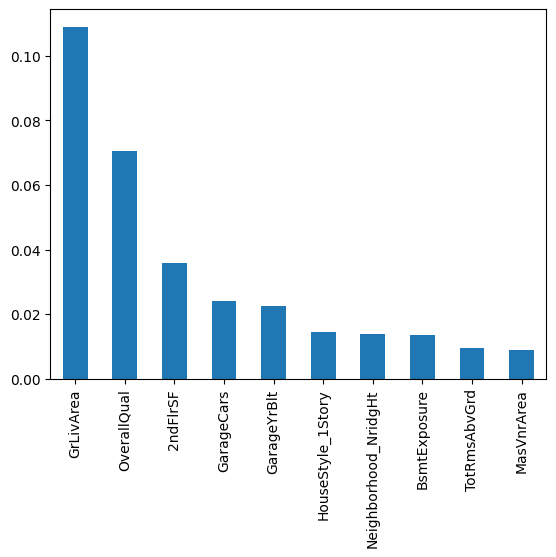

In [24]:
series = pandas.Series(feature_importances.importances_mean, index=columns)
series = series.sort_values(ascending=False).iloc[:10]
series.plot.bar()

### Caractéristiques polynômiales

Outre le travail d'extension manuel des caractéristiques, il est possible d'utiliser scikit-learn pour étendre la matrice d'apprentissage avec des caractéristiques polynômiales et sa classe [`sklearn.preprocessing.PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

In [25]:
top10 = (-feature_importances.importances_mean).argsort()[:10]


def poly_features(array: numpy.ndarray) -> numpy.ndarray:
  polynomial_features = sklearn.preprocessing.PolynomialFeatures(
    2, interaction_only=True
  )
  return polynomial_features.fit_transform(array[:, top10])


X_train_poly = poly_features(X_train)
X_test_poly = poly_features(X_test)


parametrization = nevergrad.p.Instrumentation(
  alpha=nevergrad.p.Scalar(lower=1e-3, upper=1e3),
)

optimizer = nevergrad.optimizers.NGOpt(parametrization=parametrization, budget=50)
recommendation = optimizer.minimize(loss, verbosity=0)

best_model = sklearn.linear_model.Ridge(**recommendation.kwargs)
best_model.fit(X_train_poly, Y_train_scaled)

print()
print("=" * 80)
print(f"Paramètres trouvés par Nevergrad : {recommendation.kwargs}")
print(f"score: {score(best_model)}")
print("=" * 80)


Paramètres trouvés par Nevergrad : {'alpha': 12.141987858999894}
score: 0.8302101262740884
